In [12]:
#!/usr/bin/env python
"""Run srflux on your own CSV data. Copy this file and edit the SETTINGS block.

    python examples/run_my_data.py

As shipped it runs on the example day in examples/data/, so you can check the
whole chain works before pointing it at anything of your own. Change the paths
and column names in SETTINGS below and it runs on your data instead.

What it does, in order:

    1. read a high-rate temperature CSV and a block-averaged reference CSV
    2. cut the temperature into averaging blocks
    3. detect ramps in each block and turn them into an uncalibrated flux
    4. fit the calibration coefficient alpha against the measured H
    5. apply alpha, get the flux direction, close the energy balance for ET
    6. write a per-block CSV and print a summary

What it writes:

    srflux_output.csv   one row per block: ramp statistics, calibrated H, LE, and
                        the reference H it was compared against
    srflux_output.png   H time series against the reference (only if matplotlib
                        is installed; pip install "srflux[examples]")
"""

from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

from srflux import (HaarDetector, VanAttaDetector, align_reference, blocks_from_series,
                    daily_et, fit_and_score, latent_heat_residual, load_flux_csv,
                    load_scalar_csv, prepare_block, ramp_flux, sensible_heat,
                    sign_from_skewness)

In [13]:
# ----------------------------------------------------------------------------
# SETTINGS -- this is the part you edit
# ----------------------------------------------------------------------------

HERE = Path("/Users/ajgal/srflux")

date = "2025"

# Your high-rate temperature file. One timestamp column plus one or more data
# columns, 1 Hz or faster. A .csv.gz is read directly, no need to unzip.
SCALAR_CSV = HERE / "data" / "2025" /"WES_IRT_2025_combined.dat"
SCALAR_COL = "T_CANOPY"          # which column holds the temperature [deg C]
TIME_COL = "TIMESTAMP"      # timestamp column name, in both files

# Your block-averaged reference file: one row per averaging period, holding the
# measured sensible heat flux used to calibrate, and Rn/G if you want ET.
REFERENCE_CSV = HERE / "data" / "2025" /"tower_flux_matched_2025.dat"
H_COL = "H"                 # measured sensible heat flux [W m-2]
NETRAD_COL = "NETRAD"       # net radiation [W m-2]; set to None to skip ET
G_COL = "G"                 # soil heat flux [W m-2]; set to None to skip ET

# Measurement setup.
FS = 1.0                    # sampling frequency [Hz]; None infers it from the timestamps
BLOCK_S = 1800.0            # averaging period [s], must match the reference file
Z = 5.5                     # length scale [m]: measurement height for an air
                            # temperature, canopy height for a surface temperature

# Which detector. "haar" is the more robust default; "vanatta" fits the classical
# structure-function ramp instead.
DETECTOR = "haar"

# Calibration. Leave as None to fit alpha from this dataset. Set a number to
# apply a coefficient fitted elsewhere -- which is the honest choice when you
# want to SCORE the result, since fitting and scoring on the same blocks always
# flatters the method.
# ALPHA = None
ALPHA = 2.1458 # from one week in June, July and August 2025, WES_02_IRT_combined.dat and tower_flux_matched.dat

# Flux direction. The detectors measure ramp size, not which way the heat goes.
# "skewness" infers it from the temperature itself; "reference" borrows the sign
# of the measured H, which is only for checking the rest of the chain.
SIGN_SOURCE = "skewness"
SIGN_LAG_S = 3.0            # increment lag for the skewness test [s]
SIGN_TAU = 0.0              # flip threshold; fit it with srflux.fit_skewness_sign

OUTPUT_CSV = HERE / "data" / f"srflux_output_{date}.csv"
OUTPUT_PNG = HERE / "data" / f"srflux_output_{date}.png"

/Users/ajgal/srflux/src/srflux/io.py:87: DtypeWarning: Columns (2: FW, 3: FW2, 4: T_CANOPY) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


loaded 31536000 samples of T_CANOPY (2025-01-01 00:00:00 to 2025-12-31 23:59:59)
loaded 16895 reference rows: ['LE', 'H', 'NETRAD', 'G']
16893 blocks of 1800 samples

applying alpha = 2.1458 from SETTINGS
daily ET from srflux  = 1025.22 mm
daily ET from measured H = 969.59 mm

wrote /Users/ajgal/srflux/data/srflux_output_2025.csv  (16893 rows)
wrote /Users/ajgal/srflux/data/srflux_output_2025.png


"\nloaded 6134400 samples of T_CANOPY (2025-05-30 00:00:01 to 2025-08-09 00:00:00)\nloaded 1028 reference rows: ['LE', 'H', 'NETRAD', 'G']\n1028 blocks of 1800 samples\n\nfitted alpha = 2.1458 on 1025 blocks (r = 0.79, NSE = 0.59, RMSE = 30.7 W m-2)\n  NOTE: alpha was fitted on these same blocks, so this score is optimistic.\n        Set ALPHA to a coefficient from other days to score honestly.\ndaily ET from srflux  = 111.28 mm\ndaily ET from measured H = 116.13 mm\n"

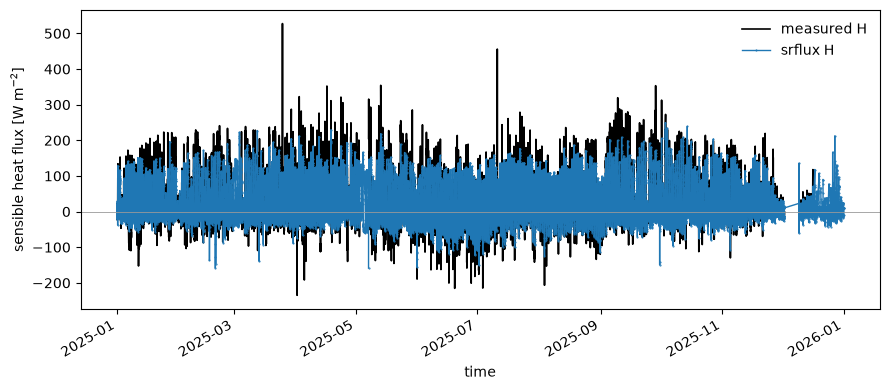

In [14]:
# ----------------------------------------------------------------------------
# From here down you should not need to change anything.
# ----------------------------------------------------------------------------
def build_detector():
    """Make the detector named in SETTINGS."""
    if DETECTOR == "haar":
        return HaarDetector(fs=FS or 1.0)
    if DETECTOR == "vanatta":
        # period_mode="unit" is the safe choice for a 1 Hz radiometric surface
        # temperature, whose fitted ramp period is too noisy to divide by
        return VanAttaDetector(fs=FS or 1.0, lag="chen", period_mode="unit")
    raise ValueError(f"DETECTOR must be 'haar' or 'vanatta', not {DETECTOR!r}")


def main() -> None:
    # --- 1. load ------------------------------------------------------------
    scalar = load_scalar_csv(SCALAR_CSV, value_col=SCALAR_COL, time_col=TIME_COL, fs=FS)
    reference = load_flux_csv(REFERENCE_CSV, time_col=TIME_COL)
    print(f"loaded {len(scalar)} samples of {SCALAR_COL} "
          f"({scalar.index[0]} to {scalar.index[-1]})")
    print(f"loaded {len(reference)} reference rows: {list(reference.columns)}")

    # --- 2. cut into blocks -------------------------------------------------
    stamps, blocks = blocks_from_series(scalar, block_s=BLOCK_S, fs=FS)
    if not blocks:
        raise SystemExit("no usable blocks -- check BLOCK_S and that the file has data")
    print(f"{len(blocks)} blocks of {len(blocks[0])} samples")

    # --- 3. detect ramps, one block at a time -------------------------------
    detector = build_detector()
    rate = FS or (len(blocks[0]) / BLOCK_S)
    rows = []
    for t, raw in zip(stamps, blocks):
        # prepare_block clips out-of-range values, fills short gaps, and rejects
        # a block that is too incomplete to trust
        qc = prepare_block(raw, fs=rate)
        if not qc.ok:
            rows.append(dict(timestamp=t, count=0, amplitude=np.nan, period=np.nan,
                             F=np.nan, sign=np.nan))
            continue

        res = detector.detect(qc.values)
        if not res.valid:
            rows.append(dict(timestamp=t, count=0, amplitude=np.nan, period=np.nan,
                             F=np.nan, sign=np.nan))
            continue

        # the two detectors use different flux forms: count/block for the front
        # picker, amplitude/period for Van Atta
        if detector.name == "haar":
            F = ramp_flux(res.amplitude, count=res.count, z=Z, block_s=BLOCK_S)
        else:
            F = ramp_flux(res.amplitude, period=res.period, z=Z, block_s=BLOCK_S)

        sign = sign_from_skewness(qc.values, fs=rate, tau=SIGN_TAU, lag_s=SIGN_LAG_S)
        rows.append(dict(timestamp=t, count=res.count, amplitude=res.amplitude,
                         period=res.period, F=float(F), sign=sign))

    out = pd.DataFrame(rows).set_index("timestamp")

    # --- 4. calibrate -------------------------------------------------------
    out["H_reference"] = align_reference(out.index, reference, H_COL)
    if ALPHA is None:
        # fit on unsigned flux against |H|: the sign is applied afterwards, so
        # letting it into the fit would flip the stable blocks twice
        fit = fit_and_score(out["F"].to_numpy(), np.abs(out["H_reference"].to_numpy()))
        alpha = fit.alpha
        print(f"\nfitted alpha = {alpha:.5g} on {fit.n} blocks "
              f"(r = {fit.r:.2f}, NSE = {fit.nse:.2f}, RMSE = {fit.rmse:.1f} W m-2)")
        print("  NOTE: alpha was fitted on these same blocks, so this score is "
              "optimistic.\n        Set ALPHA to a coefficient from other days to "
              "score honestly.")
    else:
        alpha = float(ALPHA)
        print(f"\napplying alpha = {alpha:.5g} from SETTINGS")

    # --- 5. calibrated flux, direction, and ET ------------------------------
    if SIGN_SOURCE == "reference":
        sign = np.sign(out["H_reference"].to_numpy())
    else:
        sign = out["sign"].to_numpy()
    out["H_srflux"] = sensible_heat(out["F"].to_numpy(), alpha, sign=sign)

    have_energy = NETRAD_COL in reference.columns and G_COL in reference.columns
    if have_energy:
        rn = align_reference(out.index, reference, NETRAD_COL)
        g = align_reference(out.index, reference, G_COL)
        out["LE_srflux"] = latent_heat_residual(rn, g, out["H_srflux"].to_numpy())
        et = daily_et(out["LE_srflux"].to_numpy(), block_s=BLOCK_S)
        print(f"daily ET from srflux  = {et:.2f} mm")
        if H_COL in reference.columns:
            le_ref = latent_heat_residual(rn, g, out["H_reference"].to_numpy())
            print(f"daily ET from measured H = {daily_et(le_ref, block_s=BLOCK_S):.2f} mm")
    else:
        print(f"skipping ET: need {NETRAD_COL!r} and {G_COL!r} in the reference file")

    # --- 6. write out -------------------------------------------------------
    out.to_csv(OUTPUT_CSV)
    print(f"\nwrote {OUTPUT_CSV}  ({len(out)} rows)")
    make_plot(out)


def make_plot(out: pd.DataFrame) -> None:
    """Save an H comparison figure, and show it if a display is available."""
    try:
        import matplotlib
        import matplotlib.pyplot as plt
    except ImportError:
        print('no figure written; pip install "srflux[examples]" for matplotlib')
        return

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(out.index, out["H_reference"], "k-", lw=1.2, label="measured H")
    ax.plot(out.index, out["H_srflux"], "o-", ms=0.5, lw=1.0, label="srflux H")
    ax.axhline(0, color="0.6", lw=0.6)
    ax.set_ylabel("sensible heat flux [W m$^{-2}$]")
    ax.set_xlabel("time")
    ax.legend(frameon=False)
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(OUTPUT_PNG, dpi=150)
    print(f"wrote {OUTPUT_PNG}")

if __name__ == "__main__":
    main()


'''
loaded 6134400 samples of T_CANOPY (2025-05-30 00:00:01 to 2025-08-09 00:00:00)
loaded 1028 reference rows: ['LE', 'H', 'NETRAD', 'G']
1028 blocks of 1800 samples

fitted alpha = 2.1458 on 1025 blocks (r = 0.79, NSE = 0.59, RMSE = 30.7 W m-2)
  NOTE: alpha was fitted on these same blocks, so this score is optimistic.
        Set ALPHA to a coefficient from other days to score honestly.
daily ET from srflux  = 111.28 mm
daily ET from measured H = 116.13 mm
'''

In [11]:
'''
This is a script to match timestamps between a Campbell Scientific TOA5 .dat file (or a CSV) and a tower flux CSV, and output the matched rows to a new CSV.
'''

import pandas as pd
import csv


def load_toa5_or_csv(path):
    """Load a Campbell Scientific TOA5 .dat file or a plain CSV into a DataFrame."""
    with open(path, newline="", encoding="utf-8-sig") as f:
        first_line = f.readline()

    if first_line.startswith('"TOA5"'):
        # TOA5: row0=station info, row1=column names, row2=units, row3=sample type, then data
        df = pd.read_csv(path, skiprows=[0, 2, 3], encoding="utf-8-sig")
    else:
        df = pd.read_csv(path, encoding="utf-8-sig")

    return df

irt = load_toa5_or_csv("/Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new/WES_IRT_2025_combined.dat")
irt["TIMESTAMP"] = pd.to_datetime(irt["TIMESTAMP"])
irt_timestamps = set(irt["TIMESTAMP"])

print(f"IRT file: {len(irt)} rows, {irt['TIMESTAMP'].min()} to {irt['TIMESTAMP'].max()}")

tower = load_toa5_or_csv("/Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/CSI_soil_merged/merged_all.csv")
tower["TIMESTAMP"] = pd.to_datetime(tower["TIMESTAMP"])

cols = ["TIMESTAMP", "LE", "H", "NETRAD", "G"]
missing = [c for c in cols if c not in tower.columns]
if missing:
    print(f"WARNING: these columns are not in merged_all.csv: {missing}")
    print(f"Available columns: {list(tower.columns)}")

filtered = tower.loc[tower["TIMESTAMP"].isin(irt_timestamps), [c for c in cols if c in tower.columns]]
filtered = filtered.sort_values("TIMESTAMP")

out_path = "/Users/ajgal/srflux/scratch/tower_flux_matched_2025.dat"
filtered.to_csv(out_path, index=False)

print(f"Matched {len(filtered)} of {len(irt)} IRT timestamps -> {out_path}")

/var/folders/hb/jr7_4krd23v_f8x4xyvjqqnr0000gp/T/ipykernel_89905/1589041810.py:18: DtypeWarning: Columns (2: FW, 3: FW2, 4: T_CANOPY) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding="utf-8-sig")


IRT file: 30409790 rows, 2025-01-01 00:00:00 to 2025-12-31 23:59:59
Matched 16895 of 30409790 IRT timestamps -> /Users/ajgal/srflux/scratch/tower_flux_matched_2025.dat


In [10]:
import csv
import glob
import os
from datetime import datetime


def read_toa5(path):
    with open(path, newline="", encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        header_lines = [next(reader) for _ in range(4)]
        rows = [row for row in reader if row]
    return header_lines, rows


def parse_ts(ts):
    try:
        return datetime.strptime(ts, "%Y-%m-%d %H:%M:%S")
    except ValueError:
        return None  # unparseable timestamp


def combine_toa5_files(folder, pattern, out_name, year=None):
    files = sorted(glob.glob(os.path.join(folder, pattern)))

    if not files:
        print(f"No files matched {pattern!r} in {folder!r}")
        return

    print(f"Found {len(files)} file(s):")
    for f in files:
        print(f"  {f}")

    reference_header = None
    combined = {}  # TIMESTAMP -> row, dedup + easy overwrite-on-overlap
    skipped_wrong_year = 0
    skipped_unparseable = 0

    for path in files:
        header_lines, rows = read_toa5(path)

        if reference_header is None:
            reference_header = header_lines
        elif header_lines[1:] != reference_header[1:]:  # compare columns/units/type
            print(f"  WARNING: {path} has different columns/units than the "
                  f"first file — skipping this file.")
            continue

        for row in rows:
            ts = row[0]
            if year is not None:
                dt = parse_ts(ts)
                if dt is None:
                    skipped_unparseable += 1
                    continue
                if dt.year != year:
                    skipped_wrong_year += 1
                    continue
            combined[ts] = row  # later files overwrite earlier duplicates

    if year is not None:
        if skipped_wrong_year:
            print(f"  Skipped {skipped_wrong_year} row(s) outside {year}.")
        if skipped_unparseable:
            print(f"  Skipped {skipped_unparseable} row(s) with unparseable TIMESTAMP.")

    def sort_key(ts):
        dt = parse_ts(ts)
        return dt if dt is not None else datetime.min

    sorted_rows = [combined[ts] for ts in sorted(combined, key=sort_key)]

    out_path = os.path.join(folder, out_name)
    with open(out_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f, quoting=csv.QUOTE_MINIMAL)
        writer.writerow(reference_header[1])  # column names only, e.g. TIMESTAMP,RECORD,...
        writer.writerows(sorted_rows)

    print(f"\nCombined {len(sorted_rows)} rows -> {out_path}")
    return out_path

combine_toa5_files(
    folder="/Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new",
    pattern="*.dat",
    out_name="WES_IRT_2025_combined.dat",
    year=2025,
)

Found 392 file(s):
  /Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new/WES_02_IRT_2024-12-31_000000.dat
  /Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new/WES_02_IRT_2025-01-01_000000.dat
  /Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new/WES_02_IRT_2025-01-02_000000.dat
  /Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new/WES_02_IRT_2025-01-03_000002.dat
  /Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new/WES_02_IRT_2025-01-04_000000.dat
  /Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new/WES_02_IRT_2025-01-05_000000.dat
  /Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new/WES_02_IRT_2025-01-06_000000.dat
  /Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new/WES_02_IRT_2025-01-07_000000.dat
  /Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new/WES_02_IRT_2025-01-08_000000.dat
  /Volumes/Samsung_SSD/WES/WES_tower

  Skipped 1337246 row(s) outside 2025.

Combined 30409790 rows -> /Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new/WES_IRT_2025_combined.dat


'/Volumes/Samsung_SSD/WES/WES_tower_data/converted/2025/Tower2/IRT_new/WES_IRT_2025_combined.dat'